In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

Text(0.5, 1.0, 'Blackbody Spectrum at T = 20 K')

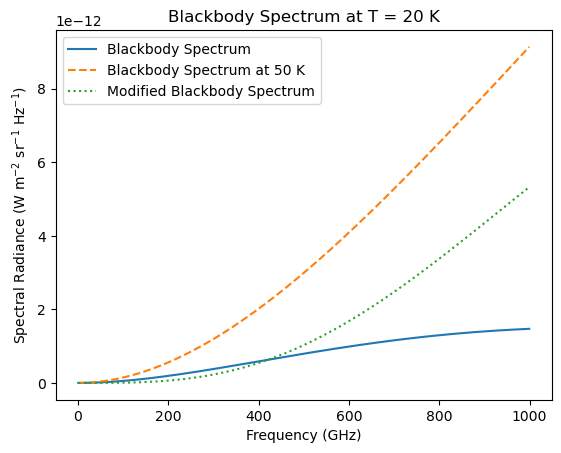

In [2]:
Adust = 1e-12 * u.erg / u.cm**2  # Amplitude of the modified blackbody in Jy/sr
nu_o = 500 * u.GHz
z = 0.01
T = 20 * u.K
beta = 1.5

nu = (np.arange(1, 1000) * u.GHz).to(u.Hz).to(u.s**-1)  # Frequency range from 1 GHz to 1000 GHz

B_nu = ((2 * const.h * nu**3) / (const.c**2)) * (1 / (np.exp(const.h * nu / (const.k_B * T)) - 1))
B_nu = B_nu.to(u.erg / u.cm**2).value  # Convert to W m^-2 sr^-1 Hz^-1

B_nu_2 = ((2 * const.h * nu**3) / (const.c**2)) * (1 / (np.exp(const.h * nu / (const.k_B * 50*u.K)) - 1))
B_nu_2 = B_nu_2.to(u.erg / u.cm**2).value  # Convert to W m^-2 sr^-1 Hz^-1

term1 = (np.exp(const.h * nu_o / (const.k_B * T)) - 1)
term2 = (np.exp(const.h * nu * (1+z) / (const.k_B * T)) - 1)


nu = (np.arange(1, 1000) * u.GHz)

Inu_mfreq = Adust * (nu * (1+z) / nu_o)**(beta+3) * term1 / term2
Inu_mfreq = Inu_mfreq.to(u.erg / u.cm**2).value  # Convert to W m^-2 sr^-1 Hz^-1

plt.plot(nu, B_nu, label='Blackbody Spectrum')
plt.plot(nu, B_nu_2, label='Blackbody Spectrum at 50 K', linestyle='--')
plt.plot(nu, Inu_mfreq, label='Modified Blackbody Spectrum', linestyle=':')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Spectral Radiance (W m$^{-2}$ sr$^{-1}$ Hz$^{-1}$)')
plt.legend()
plt.title('Blackbody Spectrum at T = 20 K')

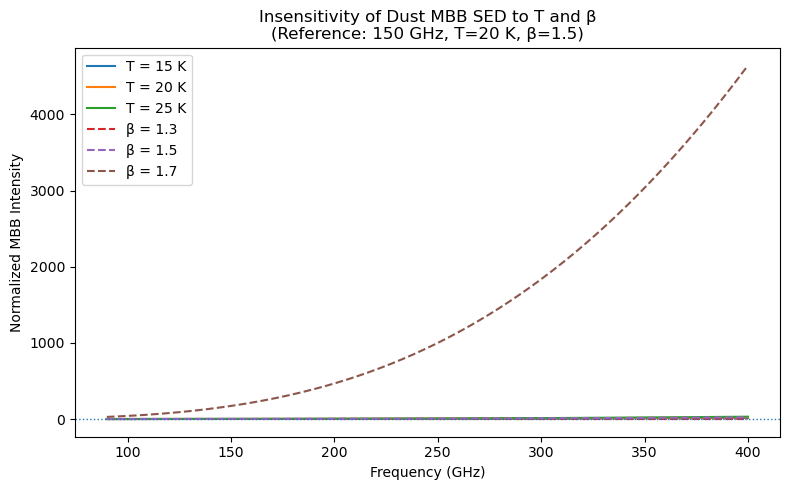

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
h = 6.626e-34  # Planck constant (J·s)
k = 1.381e-23  # Boltzmann constant (J/K)

# Modified Blackbody function
def mbb(nu, T, beta):
    return (nu**(beta + 3)) / (np.exp(h * nu / (k * T)) - 1)

# Frequency range (90–400 GHz)
frequencies = np.linspace(90e9, 400e9, 300)

# Normalize at 150 GHz for MBB with T=20K, beta=1.5
norm_factor = mbb(150e9, 20, 1.5)

plt.figure(figsize=(8, 5))

# Varying dust temperature (beta fixed at 1.5)
for T in [15, 20, 25]:
    vals = mbb(frequencies, T, 1.5) / norm_factor
    plt.plot(frequencies / 1e9, vals, label=f'T = {T} K')

# Varying spectral index (T fixed at 20 K)
for beta in [1.3, 1.5, 1.7]:
    vals = mbb(frequencies, 20, beta) / norm_factor
    plt.plot(frequencies / 1e9, vals, '--', label=f'β = {beta}')

# Reference line
plt.axhline(1, linestyle=':', linewidth=1)

# Labels and legend
plt.xlabel('Frequency (GHz)')
plt.ylabel('Normalized MBB Intensity')
plt.title('Insensitivity of Dust MBB SED to T and β\n(Reference: 150 GHz, T=20 K, β=1.5)')
plt.legend()
plt.tight_layout()

plt.show()


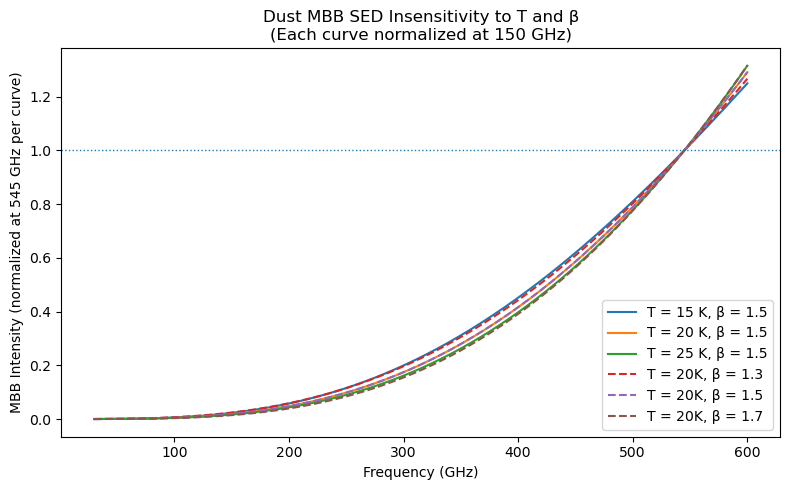

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
h = 6.626e-34  # Planck constant (J·s)
k = 1.381e-23  # Boltzmann constant (J/K)

# Modified Blackbody function
def mbb(nu, T, beta):
    nu = nu * u.Hz
    T = T * u.K
    return (nu**(beta + 3)) / (np.exp(const.h * nu / (const.k_B * T)) - 1)

# Frequency range (30–600 GHz)
frequencies = np.linspace(30e9, 600e9, 300)

plt.figure(figsize=(8, 5))

# Varying dust temperature (beta fixed at 1.5), each normalized to its own 150 GHz value
for T in [15, 20, 25]:
    norm_T = mbb(545e9, T, 1.5)
    vals = mbb(frequencies, T, 1.5) / norm_T
    plt.plot(frequencies / 1e9, vals, label=f'T = {T} K, β = 1.5')

# Varying spectral index (T fixed at 20 K), each normalized to its own 150 GHz value
for beta in [1.3, 1.5, 1.7]:
    norm_beta = mbb(545e9, 20, beta)
    vals = mbb(frequencies, 20, beta) / norm_beta
    plt.plot(frequencies / 1e9, vals, '--', label=f'T = 20K, β = {beta}')

# Reference line
plt.axhline(1, linestyle=':', linewidth=1)

# Labels and legend
plt.xlabel('Frequency (GHz)')
plt.ylabel('MBB Intensity (normalized at 545 GHz per curve)')
plt.title('Dust MBB SED Insensitivity to T and β\n(Each curve normalized at 150 GHz)')
plt.legend()
plt.tight_layout()

plt.show()


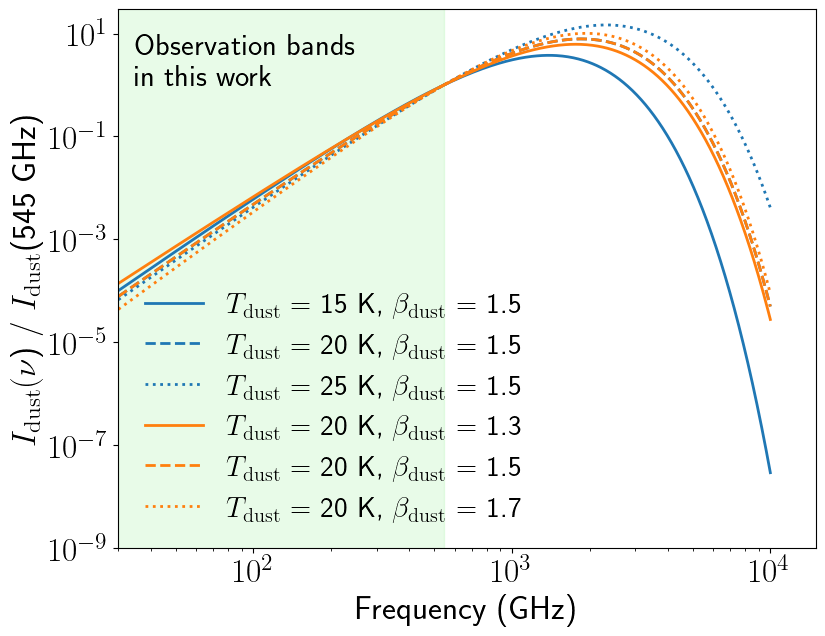

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
plt.rc('text', usetex=1)
plt.rc('font', family='sans-serif', size=24)

# Modified Blackbody function (with astropy units)
def mbb(nu, T, beta):
    # nu: Quantity in Hz, T: Quantity in K
    B = (nu**(beta+3)) / (np.exp(const.h * nu / (const.k_B * T)) - 1)
    return B.decompose()

# Frequency grid
nu = np.linspace(30, 10000, 500) * u.GHz

# Fiducial parameters
T0, beta0 = 20 * u.K, 1.5

plt.figure(figsize=(9, 7))


# Temperature variants (normalized at 545 GHz)
temp_linestyles = ['-', '--', ':']
for i, T in enumerate([15, 20, 25]):
    curve = mbb(nu, T*u.K, beta0)
    norm = mbb(545*u.GHz, T*u.K, beta0)
    plt.loglog(nu.value, (curve/norm).value, temp_linestyles[i],
               label=r'$T_{\rm dust}$ = ' + f'{T} K, ' + r'$\beta_{\rm dust}$ = 1.5', color=f'C{0}', lw=2)

# β variants (normalized at 545 GHz)
beta_linestyles = ['-', '--', ':']
for i, beta in enumerate([1.3, 1.5, 1.7]):
    curve = mbb(nu, T0, beta)
    norm = mbb(545*u.GHz, T0, beta)
    plt.loglog(nu.value, (curve/norm).value, beta_linestyles[i],
               label=r'$T_{\rm dust}$ = ' + f'20 K, ' + r'$\beta_{\rm dust}$ = ' +f'{beta}', color=f'C{1}', lw=2)

# Reference line
# plt.axhline(1, color='gray', linestyle='--')
# plt.axvline(545, color='gray', linestyle='--')

plt.fill_betweenx(
    y=np.linspace(10**-18, 10**2., 2),
    x1=30, x2=545,
    color='lightgreen', alpha=0.2, zorder=0
)

plt.text(x=10**1.54, y=10 * 10**-1, s="Observation bands \nin this work", fontsize=22)

plt.xlabel('Frequency (GHz)')
plt.ylabel(r'$I_{\rm dust}(\nu$) / $I_{\rm dust}$(545 GHz)')
plt.xlim(30, 1.5*10**4)
plt.ylim(10**-9, 30)
plt.legend(loc='lower left', fontsize=21, frameon=0)
plt.savefig('../plots/dust_bands.pdf', bbox_inches='tight', dpi=400, format='pdf')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const

plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=16)

# Modified Blackbody function (with astropy units)
def mbb(nu, T, beta):
    B = (nu**(beta + 3) / (np.exp(const.h * nu / (const.k_B * T)) - 1))
    return B.decompose()

# Frequency grid
nu = np.linspace(30, 10000, 500) * u.GHz

# Fiducial parameters
T_vals = [15, 20, 25]
beta_vals = [1.3, 1.5, 1.7]
pivot = 545 * u.GHz

# Define consistent colors for mapping
colors = ['C0', 'C1', 'C2']  # will map 15K↔1.3, 20K↔1.5, 25K↔1.7

plt.figure(figsize=(9, 6))

# Plot temperature variants at fixed beta0 with solid lines
beta0 = 1.5
for i, T in enumerate(T_vals):
    curve = mbb(nu, T * u.K, beta0)
    norm = mbb(pivot, T * u.K, beta0)
    plt.loglog(nu.value, (curve / norm).value, '-', color=colors[i],
               label=f'$T={T}\\,$K, $\\beta={beta0}$')

# Plot beta variants at fixed T0 with dashed lines, using same color mapping
T0 = 20 * u.K
for i, beta in enumerate(beta_vals):
    curve = mbb(nu, T0, beta)
    norm = mbb(pivot, T0, beta)
    plt.loglog(nu.value, (curve / norm).value, '--', color=colors[i],
               label=f'$T={T0.value}\\,$K, $\\beta={beta}$')

# Reference lines
plt.axhline(1, color='gray', linestyle=':')
plt.axvline(pivot.value, color='gray', linestyle='--')

plt.xlabel('Frequency (GHz)')
plt.ylabel(r'I($\nu$) / I(545 GHz)')
plt.title('Dust MBB SED vs. Frequency\n(Log–Log, normalized at 545 GHz)')
plt.legend(loc='lower left', fontsize=14, frameon=False)
plt.tight_layout()
plt.show()
